In [83]:
import torch
import matplotlib.pyplot as plt


t_u = torch.tensor([0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0])
t_f = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4])

In [84]:
def model(t_f, w1, w2, b):
    return w2 * t_f ** 2 + w1 * t_f + b

In [85]:
def loss_fn(t_p, t_u):
    squared_errors = (t_p - t_u) ** 2
    return squared_errors.mean()

In [ ]:
# Training loop
def training_loop(n_epochs, optimizer, params, t_f, t_u):
    w1, w2, b = params
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_f, w1, w2, b)  # Predictions
        loss = loss_fn(t_p, t_u)  # Compute loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Compute gradients
        optimizer.step()  # Update parameters

        if epoch % 500 == 0 or epoch == 1:
            print(f"Epoch {epoch}, Loss {loss.item():.4f}")

In [87]:
# Initialize parameters
w1 = torch.randn((), requires_grad=True)
w2 = torch.randn((), requires_grad=True)
b = torch.randn((), requires_grad=True)

In [88]:
params = [w1, w2, b]

In [89]:
optimizer = torch.optim.SGD(params, lr=1e-9)

In [90]:
training_loop(n_epochs=2000, optimizer=optimizer, params=params, t_f=t_f, t_u=t_u)

Epoch 1, Loss 244266.1875
Epoch 500, Loss 35.2180
Epoch 1000, Loss 35.2088
Epoch 1500, Loss 35.1996
Epoch 2000, Loss 35.1905


In [91]:
t_f_range = torch.linspace(min(t_f), max(t_f), 100)

In [92]:
t_p_range = model(t_f_range, w1, w2, b).detach()

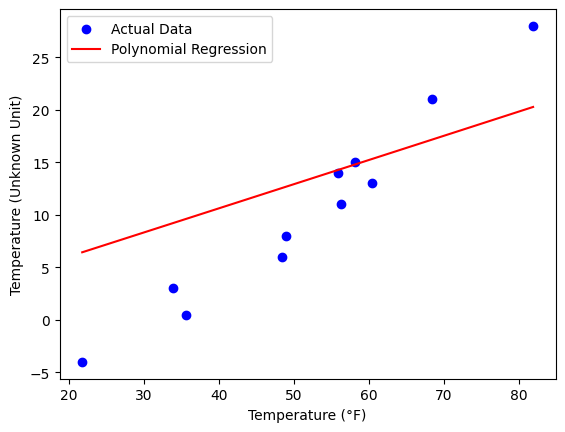

In [93]:
plt.scatter(t_f, t_u, label="Actual Data", color='blue')
plt.plot(t_f_range, t_p_range, label="Polynomial Regression", color='red')
plt.xlabel("Temperature (°F)")
plt.ylabel("Temperature (Unknown Unit)")
plt.legend()
plt.show()